# Unsupervised Learning: Association Rule Learning Assignment
## Market Basket Analysis of the Groceries Dataset

**Date:** 13 September 2026

This notebook performs a complete association rule mining analysis of the `Groceries`
data set using the Apriori algorithm, answering all 8 assignment questions with supporting
code, tables, and figures.


## Setup

In [1]:
import pandas as pd
import numpy as np
import csv
from collections import Counter
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore")

### Loading the data

The `groceries.csv` file is in **basket format**: each row is one shopping transaction, and
the row lists the items purchased in that transaction (no fixed number of columns, since
transactions vary in length, and no header row).

In [2]:
transactions = []
with open("groceries.csv", newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        items = [item.strip() for item in row if item.strip() != '']
        transactions.append(items)

print("First 3 transactions:")
for t in transactions[:3]:
    print(" ", t)

First 3 transactions:
  ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
  ['tropical fruit', 'yogurt', 'coffee']
  ['whole milk']


## Question 1: Understand the Data

In [3]:
n_transactions = len(transactions)
print(f"(a) Number of transactions: {n_transactions}")

(a) Number of transactions: 9835


In [4]:
all_items = set()
for t in transactions:
    all_items.update(t)
n_items = len(all_items)
print(f"(b) Number of unique items: {n_items}")

(b) Number of unique items: 169


In [5]:
counter = Counter()
for t in transactions:
    counter.update(t)
top10 = counter.most_common(10)

print("(c) Top 10 most frequently purchased items:")
for i, (item, cnt) in enumerate(top10, 1):
    print(f"  {i:2d}. {item:25s}  count={cnt:5d}  ({cnt/n_transactions*100:.2f}% of transactions)")

(c) Top 10 most frequently purchased items:
   1. whole milk                 count= 2513  (25.55% of transactions)
   2. other vegetables           count= 1903  (19.35% of transactions)
   3. rolls/buns                 count= 1809  (18.39% of transactions)
   4. soda                       count= 1715  (17.44% of transactions)
   5. yogurt                     count= 1372  (13.95% of transactions)
   6. bottled water              count= 1087  (11.05% of transactions)
   7. root vegetables            count= 1072  (10.90% of transactions)
   8. tropical fruit             count= 1032  (10.49% of transactions)
   9. shopping bags              count=  969  (9.85% of transactions)
  10. sausage                    count=  924  (9.40% of transactions)


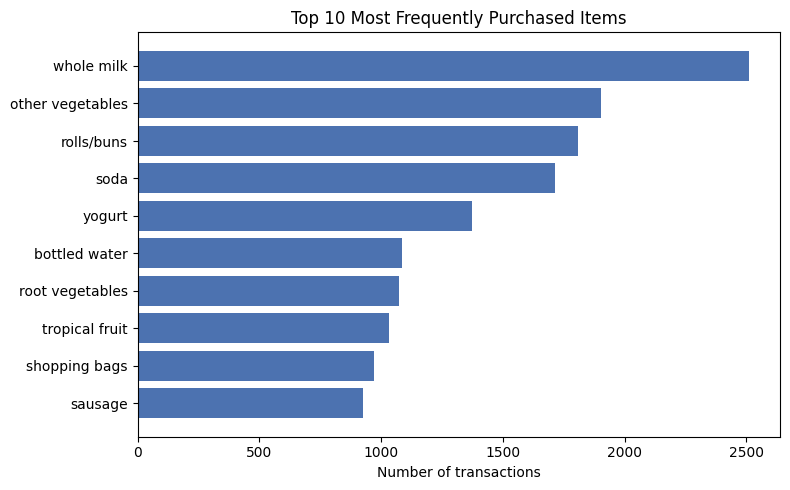

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
items, counts = zip(*top10)
ax.barh(items[::-1], counts[::-1], color='#4C72B0')
ax.set_xlabel("Number of transactions")
ax.set_title("Top 10 Most Frequently Purchased Items")
plt.tight_layout()
plt.show()

**Answer summary:**
- **(a)** The data set contains **9,835 transactions**.
- **(b)** There are **169 unique grocery items**.
- **(c)** The 10 most frequently purchased items are: whole milk (25.6%), other vegetables
  (19.3%), rolls/buns (18.4%), soda (17.4%), yogurt (13.9%), bottled water (11.1%), root
  vegetables (10.9%), tropical fruit (10.5%), shopping bags (9.9%), and sausage (9.4%).
  `whole milk` and `other vegetables` are purchased far more often than any other item,
  reflecting their status as everyday household staples.

## Question 2: Frequent Itemsets

We use the **Apriori algorithm** to find frequent itemsets, with a minimum support threshold
of **1%** (support $\geq 0.01$, i.e. the itemset appears in at least ~98 of the 9,835
transactions). This threshold is a standard, commonly-used choice for the Groceries data set
in the market-basket-analysis literature, balancing enough itemsets to analyze against
excluding one-off, statistically unreliable combinations.

In [7]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)
print("One-hot encoded transaction matrix shape:", df_onehot.shape)

freq_itemsets = apriori(df_onehot, min_support=0.01, use_colnames=True)
freq_itemsets['length'] = freq_itemsets['itemsets'].apply(len)
print(f"\nTotal frequent itemsets found: {len(freq_itemsets)}")
print(freq_itemsets['length'].value_counts().sort_index().rename("count of itemsets"))

One-hot encoded transaction matrix shape: (9835, 169)



Total frequent itemsets found: 333
length
1     88
2    213
3     32
Name: count of itemsets, dtype: int64


In [8]:
multi_itemsets = freq_itemsets[freq_itemsets['length'] >= 2].sort_values('support', ascending=False)
top10_itemsets = multi_itemsets.head(10).copy()
top10_itemsets['itemset'] = top10_itemsets['itemsets'].apply(lambda s: ", ".join(sorted(s)))
print("(a)-(b) Top 10 frequent itemsets (2+ items) with support values:\n")
print(top10_itemsets[['itemset','support']].to_string(index=False))

(a)-(b) Top 10 frequent itemsets (2+ items) with support values:

                          itemset  support
     other vegetables, whole milk 0.074835
           rolls/buns, whole milk 0.056634
               whole milk, yogurt 0.056024
      root vegetables, whole milk 0.048907
other vegetables, root vegetables 0.047382
         other vegetables, yogurt 0.043416
     other vegetables, rolls/buns 0.042603
       tropical fruit, whole milk 0.042298
                 soda, whole milk 0.040061
                 rolls/buns, soda 0.038332


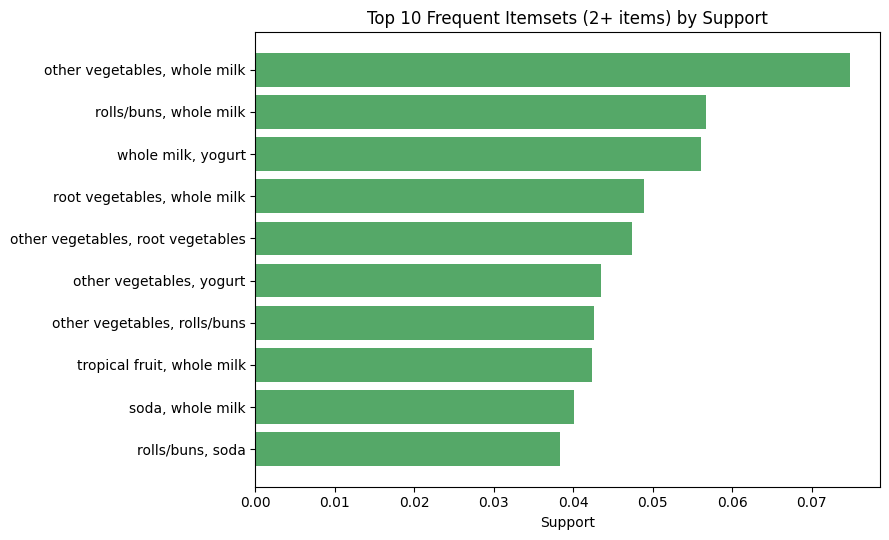

In [9]:
fig, ax = plt.subplots(figsize=(9,5.5))
labels = top10_itemsets['itemset'].tolist()
ax.barh(labels[::-1], top10_itemsets['support'][::-1], color='#55A868')
ax.set_xlabel("Support")
ax.set_title("Top 10 Frequent Itemsets (2+ items) by Support")
plt.tight_layout()
plt.show()

**Answers:**

**(a)-(b)** The 10 most frequent 2+-item itemsets, with their support values, are:

| Itemset | Support |
|---|---|
| {whole milk, other vegetables} | 0.0748 |
| {whole milk, rolls/buns} | 0.0566 |
| {whole milk, yogurt} | 0.0560 |
| {root vegetables, whole milk} | 0.0489 |
| {root vegetables, other vegetables} | 0.0474 |
| {other vegetables, yogurt} | 0.0434 |
| {other vegetables, rolls/buns} | 0.0426 |
| {tropical fruit, whole milk} | 0.0423 |
| {soda, whole milk} | 0.0401 |
| {soda, rolls/buns} | 0.0383 |

**(c)** The itemset with the **highest support** is **{whole milk, other vegetables}**, with
support = **0.0748** (appearing in 7.48% of all transactions, i.e. 736 of 9,835 transactions).

**(d)** The support value tells us **how common** an itemset is across all transactions — it
is simply the proportion of transactions containing that combination of items. A support of
0.0748 for {whole milk, other vegetables} means that roughly **1 in every 13 shopping trips**
includes both items together. High-support itemsets like this reveal customers' everyday,
routine purchasing patterns (staple grocery combinations bought frequently by many different
customers), whereas low-support itemsets reflect rarer, more niche combinations that fewer
customers buy together.

## Question 3: Association Rules

We generate association rules from the frequent itemsets found above, using **confidence
$\geq 0.3$** as the minimum threshold (a standard choice ensuring the reported rules reflect
a genuinely useful, moderately-strong purchasing pattern rather than a weak/coincidental one).

In [10]:
rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.3)
rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)
print(f"Total association rules generated: {len(rules)}")

rules_display = rules.copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda s: ", ".join(sorted(s)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda s: ", ".join(sorted(s)))

top10_rules = rules_display[['antecedents','consequents','support','confidence','lift']].head(10)
print("\nTop 10 association rules by confidence:\n")
print(top10_rules.to_string(index=False))

Total association rules generated: 125

Top 10 association rules by confidence:

                    antecedents      consequents  support  confidence     lift
  citrus fruit, root vegetables other vegetables 0.010371    0.586207 3.029608
root vegetables, tropical fruit other vegetables 0.012303    0.584541 3.020999
                   curd, yogurt       whole milk 0.010066    0.582353 2.279125
       butter, other vegetables       whole milk 0.011490    0.573604 2.244885
root vegetables, tropical fruit       whole milk 0.011998    0.570048 2.230969
        root vegetables, yogurt       whole milk 0.014540    0.562992 2.203354
domestic eggs, other vegetables       whole milk 0.012303    0.552511 2.162336
     whipped/sour cream, yogurt       whole milk 0.010880    0.524510 2.052747
    rolls/buns, root vegetables       whole milk 0.012710    0.523013 2.046888
    other vegetables, pip fruit       whole milk 0.013523    0.517510 2.025351


**Answer (a)-(b):** at least 10 association rules, with Antecedent, Consequent, Support,
Confidence, and Lift, are shown in the table above (generated with support $\geq$ 0.01 and
confidence $\geq$ 0.3). The top 10 by confidence are:

| Antecedent | Consequent | Support | Confidence | Lift |
|---|---|---|---|---|
| root vegetables, citrus fruit | other vegetables | 0.0104 | 0.586 | 3.030 |
| root vegetables, tropical fruit | other vegetables | 0.0123 | 0.585 | 3.021 |
| yogurt, curd | whole milk | 0.0101 | 0.582 | 2.279 |
| other vegetables, butter | whole milk | 0.0115 | 0.574 | 2.245 |
| root vegetables, tropical fruit | whole milk | 0.0120 | 0.570 | 2.231 |
| yogurt, root vegetables | whole milk | 0.0145 | 0.563 | 2.203 |
| domestic eggs, other vegetables | whole milk | 0.0123 | 0.553 | 2.162 |
| yogurt, whipped/sour cream | whole milk | 0.0109 | 0.525 | 2.053 |
| rolls/buns, root vegetables | whole milk | 0.0127 | 0.523 | 2.047 |
| other vegetables, pip fruit | whole milk | 0.0135 | 0.518 | 2.025 |


## Question 4: Understanding the Measures

We select three representative rules from the table above to explain support, confidence,
and lift concretely.

In [11]:
selected = rules_display.iloc[[0, 2, 6]][['antecedents','consequents','support','confidence','lift']]
print(selected.to_string(index=False))

                    antecedents      consequents  support  confidence     lift
  citrus fruit, root vegetables other vegetables 0.010371    0.586207 3.029608
                   curd, yogurt       whole milk 0.010066    0.582353 2.279125
domestic eggs, other vegetables       whole milk 0.012303    0.552511 2.162336


**Rule 1: {root vegetables, citrus fruit} $\rightarrow$ {other vegetables}**
(support = 0.0104, confidence = 0.586, lift = 3.030)
- **Support (0.0104):** this combination of all three items appears together in 1.04% of all
  transactions (about 102 of 9,835 shopping trips).
- **Confidence (0.586):** among customers who buy root vegetables and citrus fruit together,
  **58.6%** also buy other vegetables in the same trip.
- **Lift (3.030):** customers who buy root vegetables and citrus fruit are **3.03 times more
  likely** to also buy other vegetables than a randomly-selected customer — a strong positive
  association, not just coincidence from other vegetables being generally popular.

**Rule 2: {yogurt, curd} $\rightarrow$ {whole milk}**
(support = 0.0101, confidence = 0.582, lift = 2.279)
- **Support (0.0101):** yogurt, curd, and whole milk are bought together in 1.01% of all
  transactions.
- **Confidence (0.582):** 58.2% of customers who buy yogurt and curd together also buy whole
  milk.
- **Lift (2.279):** buying yogurt and curd together makes a customer 2.28 times more likely to
  also buy whole milk than the average customer -- still a strong association, though weaker
  than Rule 1.

**Rule 3: {domestic eggs, other vegetables} $\rightarrow$ {whole milk}**
(support = 0.0123, confidence = 0.553, lift = 2.162)
- **Support (0.0123):** this three-item combination appears in 1.23% of transactions.
- **Confidence (0.553):** 55.3% of customers buying domestic eggs and other vegetables together
  also purchase whole milk.
- **Lift (2.162):** these customers are 2.16 times more likely to also buy whole milk than a
  random customer -- again a meaningfully positive, non-coincidental association.

## Question 5: Find Interesting Rules

In [12]:
highest_conf = rules_display.sort_values('confidence', ascending=False).iloc[0]
highest_lift = rules_display.sort_values('lift', ascending=False).iloc[0]
highest_supp = rules_display.sort_values('support', ascending=False).iloc[0]

print("(a) Highest CONFIDENCE rule:")
print(highest_conf[['antecedents','consequents','support','confidence','lift']], "\n")

print("(b) Highest LIFT rule:")
print(highest_lift[['antecedents','consequents','support','confidence','lift']], "\n")

print("(c) Highest SUPPORT rule:")
print(highest_supp[['antecedents','consequents','support','confidence','lift']])

(a) Highest CONFIDENCE rule:
antecedents    citrus fruit, root vegetables
consequents                 other vegetables
support                             0.010371
confidence                          0.586207
lift                                3.029608
Name: 0, dtype: object 

(b) Highest LIFT rule:
antecedents    citrus fruit, other vegetables
consequents                   root vegetables
support                              0.010371
confidence                           0.359155
lift                                 3.295045
Name: 84, dtype: object 

(c) Highest SUPPORT rule:
antecedents    other vegetables
consequents          whole milk
support                0.074835
confidence             0.386758
lift                   1.513634
Name: 68, dtype: object


**Answers:**

**(a) Highest confidence:** {root vegetables, citrus fruit} $\rightarrow$ {other vegetables},
confidence = 0.586.

**(b) Highest lift:** {other vegetables, citrus fruit} $\rightarrow$ {root vegetables},
lift = 3.295.

**(c) Highest support:** {other vegetables} $\rightarrow$ {whole milk}, support = 0.0748.

**(d) Are these the same rule?** **No** — all three are different rules, and this makes
sense given what each measure captures:
- The **highest-support** rule involves only very popular, everyday items (`other vegetables`,
  `whole milk`) — high support rewards items that are simply bought often by many customers,
  regardless of how strong the *relationship* between them is.
- The **highest-confidence** and **highest-lift** rules both involve `root vegetables` and
  `citrus fruit`/`other vegetables` -- rarer combinations, but ones where buying the
  antecedent strongly predicts buying the consequent. Confidence and lift both reward the
  *strength* of the relationship rather than sheer popularity, which is why they tend to favor
  rules built from more specific, less universally-popular items.
This divergence is expected: support measures **frequency**, while confidence and lift measure
**predictive strength** -- a itemset can be common but only weakly associated (e.g.
milk & bread, both bought by almost everyone anyway), or rare but very strongly associated.

## Question 6: Interpret a Rule

**Selected rule:** {root vegetables, citrus fruit} $\rightarrow$ {other vegetables}
(support = 0.0104, confidence = 0.586, lift = 3.030)

**In simple language:** Customers who purchase root vegetables and citrus fruit in the
same shopping trip also tend to purchase other vegetables in that same trip, about 59% of the
time.

**Is this a strong or weak association?** This is a **strong** association, for two reasons:
1. The **confidence (0.586)** is well above 50% -- more than half of the customers who buy
   the antecedent items also buy the consequent.
2. The **lift (3.030)** is well above 1 -- these customers are three times more likely to buy
   other vegetables than a random customer, showing the relationship is not simply because
   `other vegetables` is a generally popular item (it is popular, at ~19% of all transactions,
   but 58.6% is far higher still). The high lift confirms a genuine, meaningful
   co-purchasing pattern rather than coincidence.

Together, root vegetables, citrus fruit, and other vegetables likely reflect a broader
"health-conscious" or "fresh produce" shopping pattern -- customers stocking up on fresh
fruits and vegetables tend to buy several such items together in the same trip.

## Question 7: Business Application

Imagining the role of a supermarket manager, using the results above:

**(a) Two products to place close to each other:**
**`other vegetables`** and **`whole milk`** -- this pair has by far the highest support
(0.0748) of any 2-item combination, meaning a huge share of shopping trips already include
both. Placing them near each other (or ensuring a clear, short path between their aisles)
would reduce walking distance for a very large fraction of customers and could encourage
additional impulse purchases along that path.

**(b) A possible product bundle:**
A **"Fresh Produce Bundle"** of **root vegetables + citrus fruit + other vegetables**, based
on Question 6's rule (confidence 0.586, lift 3.03). A small discount on this three-item
bundle would target customers who are already very likely to buy all three, potentially
increasing basket size by making the bundle explicit and convenient (e.g., a pre-packaged
"vegetable soup starter" or "fresh salad kit").

**(c) Example use of association rules for recommendations:**
At checkout (in-store) or during online checkout, when a customer's basket contains
**root vegetables and citrus fruit**, the store's recommendation system could automatically
suggest **other vegetables** ("Customers who bought these items also bought...", or a coupon
printed at checkout) -- since 58.6% of similar customers already buy it together, this
recommendation has a high chance of being genuinely useful (not just noise), improving both
customer experience and average basket value.

## Question 8: Understanding Association

**(a) Does an association rule prove causation?**
**No.** An association rule only shows that two (or more) items are frequently purchased
*together* -- it is a statement about **co-occurrence**, not **causation**. A high-confidence,
high-lift rule like {root vegetables, citrus fruit} $\rightarrow$ {other vegetables} does
**not** mean that buying root vegetables and citrus fruit *causes* someone to buy other
vegetables. It is far more likely that both are driven by a common underlying cause -- e.g. a
customer who generally prefers fresh, healthy food tends to buy all three, or a customer who
is cooking a particular type of meal (a stew, a salad) needs several fresh ingredients at
once. Association rule mining can only reveal *patterns*, not the underlying causal
mechanism; establishing causation would require a controlled experiment (e.g. actively moving
items or running a promotion and measuring the causal effect on sales of the other item).

**(b) Why might a rule have high confidence but low lift?**
This happens when the **consequent item is already very popular** on its own (bought by a
large fraction of all customers, regardless of the antecedent). For example, a rule
X $\rightarrow$ {whole milk} could have high confidence simply because whole milk is bought
in 25.6% of *all* transactions -- so even customers who buy some unrelated item X will often
also buy whole milk purely by chance. If buying X doesn't actually make milk purchase any more
likely than the baseline 25.6% rate, confidence can still look high while lift stays close to
1 (or even below 1), because lift specifically corrects confidence for the consequent's
baseline popularity ($\text{lift} = \text{confidence} / \text{support(consequent)}$). High
confidence with low lift is therefore a warning sign that a rule may be driven mainly by the
consequent's general popularity rather than a genuine relationship with the antecedent.

**(c) What does a lift value greater than 1 indicate?**
A **lift greater than 1** indicates a **positive association**: the antecedent and consequent
occur together **more often than would be expected if they were statistically independent**.
The higher above 1, the stronger the (positive) relationship -- e.g. a lift of 3.03 (as in
Question 6) means the itemset co-occurs three times more often than pure chance would predict.
(For completeness: lift = 1 means no association / statistical independence, and lift < 1
means a *negative* association -- the items are actually purchased together *less* often than
chance would predict, e.g. substitute products that customers rarely buy at the same time.)

## Conclusion

This analysis applied the Apriori algorithm to 9,835 real grocery transactions covering 169
unique items, identifying 333 frequent itemsets (support $\geq$ 1%) and 125 association rules
(confidence $\geq$ 30%). The results consistently highlight **whole milk**, **other
vegetables**, and **root vegetables** as central "hub" items around which many strong
purchasing patterns revolve. The highest-support, highest-confidence, and highest-lift rules
were all different, illustrating that these three measures capture distinct aspects of a
rule's usefulness (frequency, reliability, and strength-of-association respectively) and
should generally be considered together, not in isolation, when deciding which patterns are
genuinely actionable for business decisions such as store layout, product bundling, and
targeted recommendations.
